In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
project_root = Path.cwd().parent

clean_train_dir = project_root / "data" / "clean_train"
noisy_train_dir = project_root / "data" / "noisy_train"

clean_files = sorted(clean_train_dir.rglob("*.wav"))
noisy_files = sorted(noisy_train_dir.rglob("*.wav"))

print("Clean files:", len(clean_files))
print("Noisy files:", len(noisy_files)) 

Clean files: 11572
Noisy files: 11572


In [4]:
clean_path = clean_files[0]
noisy_path = noisy_train_dir / clean_path.name

print("Clean:", clean_path)
print("Noisy:", noisy_path)

Clean: c:\Users\ohkab\audio-denoising\data\clean_train\p226_001.wav
Noisy: c:\Users\ohkab\audio-denoising\data\noisy_train\p226_001.wav


In [5]:
TARGET_SR = 16000

clean, clean_sr = sf.read(clean_path)
noisy, noisy_sr = sf.read(noisy_path)

print("Original sample rate:", clean_sr)

clean_16k = librosa.resample(
    clean,
    orig_sr=clean_sr,
    target_sr=TARGET_SR
)

noisy_16k = librosa.resample(
    noisy,
    orig_sr=noisy_sr,
    target_sr=TARGET_SR
)

print("New clean shape:", clean_16k.shape)
print("New noisy shape:", noisy_16k.shape)
print("New sample rate:", TARGET_SR)

print("Clean duration:", len(clean_16k) / TARGET_SR)
print("Noisy duration:", len(noisy_16k) / TARGET_SR)

Original sample rate: 48000
New clean shape: (36480,)
New noisy shape: (36480,)
New sample rate: 16000
Clean duration: 2.28
Noisy duration: 2.28


In [6]:
SEGMENT_SECONDS = 1.0
SEGMENT_LENGTH = int(TARGET_SR * SEGMENT_SECONDS)

print("Segment length:", SEGMENT_LENGTH)

Segment length: 16000


In [7]:
clean_segment = clean_16k[:SEGMENT_LENGTH]
noisy_segment = noisy_16k[:SEGMENT_LENGTH]

print("Clean segment:", clean_segment.shape)
print("Noisy segment:", noisy_segment.shape)

Clean segment: (16000,)
Noisy segment: (16000,)


In [8]:
noise_segment = noisy_segment - clean_segment

noise_rms = np.sqrt(np.mean(noise_segment ** 2))

signal_power = np.mean(clean_segment ** 2)
noise_power = np.mean(noise_segment ** 2)

snr = 10 * np.log10(signal_power / noise_power)

print("Noise RMS:", noise_rms)
print(f"SNR: {snr:.2f} dB")

Noise RMS: 0.01607956548315693
SNR: 14.32 dB


In [9]:
from IPython.display import Audio, display

print("CLEAN")
display(Audio(clean_segment, rate=TARGET_SR))

print("NOISY")
display(Audio(noisy_segment, rate=TARGET_SR))

CLEAN


NOISY


In [10]:
N_FFT = 512
HOP_LENGTH = 128

clean_stft = librosa.stft(
    clean_segment,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

noisy_stft = librosa.stft(
    noisy_segment,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

print("Clean STFT:", clean_stft.shape)
print("Noisy STFT:", noisy_stft.shape)

Clean STFT: (257, 126)
Noisy STFT: (257, 126)


In [ ]:
N_FFT = 512
HOP_LENGTH = 128

clean_stft = librosa.stft(
    clean_segment,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

noisy_stft = librosa.stft(
    noisy_segment,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

print("Clean STFT:", clean_stft.shape)
print("Noisy STFT:", noisy_stft.shape)

Clean STFT: (257, 126)
Noisy STFT: (257, 126)


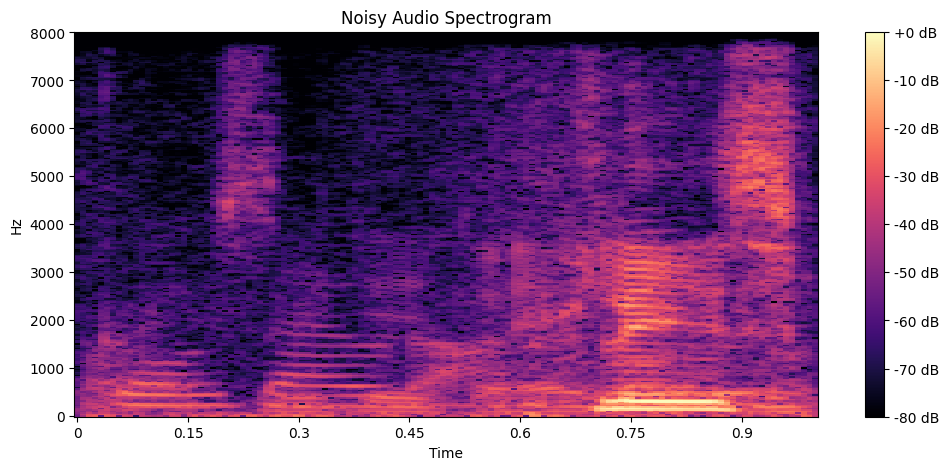

In [11]:
noisy_magnitude = np.abs(noisy_stft)

noisy_db = librosa.amplitude_to_db(
    noisy_magnitude,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    noisy_db,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Noisy Audio Spectrogram")

plt.show()

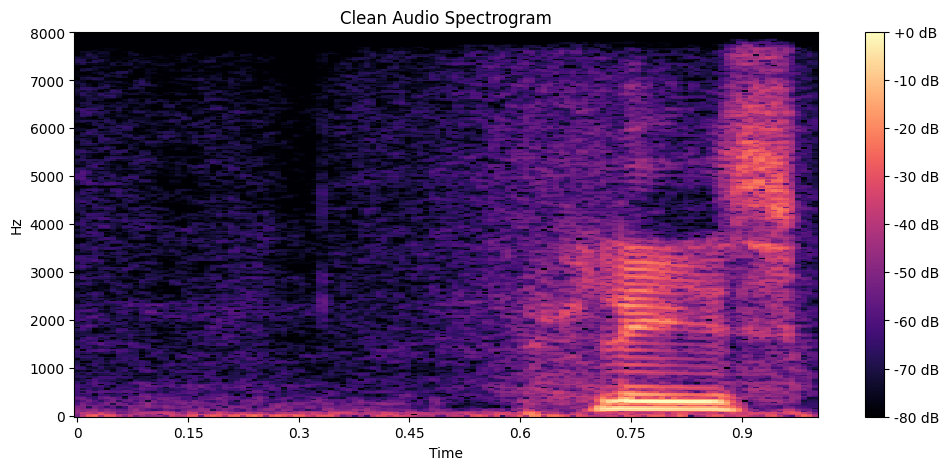

In [12]:
clean_magnitude = np.abs(clean_stft)

clean_db = librosa.amplitude_to_db(
    clean_magnitude,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    clean_db,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Clean Audio Spectrogram")

plt.show()

In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

from src.dataset import AudioDenoisingDataset

In [14]:
clean_dir = project_root / "data" / "clean_train"
noisy_dir = project_root / "data" / "noisy_train"

dataset = AudioDenoisingDataset(
    clean_dir=clean_dir,
    noisy_dir=noisy_dir
)

print("Dataset length:", len(dataset))

Dataset loaded: 11572 pairs
Dataset length: 11572


In [15]:
noisy_tensor, clean_tensor = dataset[0]

print("Noisy tensor shape:", noisy_tensor.shape)
print("Clean tensor shape:", clean_tensor.shape)

Noisy tensor shape: torch.Size([1, 257, 126])
Clean tensor shape: torch.Size([1, 257, 126])


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [17]:
noisy_batch, clean_batch = next(iter(train_loader))

print("Noisy batch shape:", noisy_batch.shape)
print("Clean batch shape:", clean_batch.shape)

Noisy batch shape: torch.Size([4, 1, 257, 126])
Clean batch shape: torch.Size([4, 1, 257, 126])


In [18]:
import sys

sys.path.append(str(project_root))

from src.model import UNet

model = UNet()

print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3

In [20]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 481745
Trainable parameters: 481745
